# TALENT ARENA: 
## Domina la IA para el análisis de datos sin código



### 1 Install pandas ai and the openai llm extension

PandasAI supports various [large language models](/v3/llms) (LLMs) to power its natural language query capabilities. OpenAI's models are available through a dedicated extension.

In [ ]:
#install pandas ai library
%pip install pandasai

In [ ]:
#install pandas ai openai extension
%pip install pandasai-openai


### 2 Load OpenAI LLM

Once you have installed the pandasai-openai extension, import the OpenAI class, and pass your OpenAI  API token as an argument.

In [1]:
import pandasai as pai
import os
from pandasai_openai import OpenAI

llm = OpenAI(api_token=os.getenv('OPEN_AI_KEY'))

/Users/josetorre/Desktop/ws-pandas-ai/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


(optional) You can check information about the llm model as it follows:

In [3]:

# Print LLM configuration to verify setup
print(f"LLM Type: {type(llm)}")
print(f"LLM Configuration:")
print(f"- Model: {llm.model}")  # Changed from model_name to model
print(f"- Temperature: {llm.temperature}")
print(f"- Max Tokens: {llm.max_tokens}")

LLM Type: <class 'pandasai_openai.openai.OpenAI'>
LLM Configuration:
- Model: gpt-4o-mini
- Temperature: 0
- Max Tokens: 1000


### 3 Configure OpenAI LLM in PandaAI

You can now set your OpenAI LLM as the default llm for PandaAI by simply passing the llm instance to the config via the `set()` method

In [4]:
pai.config.set({
    "llm": llm,
})

(optional) Check the LLM has been correctly configured

In [5]:
config = pai.config.get()
print(f"- LLM in config: {type(config.llm).__name__}")

- LLM in config: OpenAI


### 4 Chat with your data

Once you have configured the llm, you can chat with one or multiple dataframes using the chat() method. 

In [6]:
df = pai.read_csv("./data/nba_players_dataset.csv")

In [7]:
response = df.chat('Que jugadores que han jugado en los Kings y en los Heat? Indicame los puntos y temporadas de todos ellos')
print(response)

         player_name  total_points  \
0         Mike Bibby         114.4   
1   Hassan Whiteside          79.0   
2     Jason Williams          66.5   
3        Brian Grant          54.0   
4      James Johnson          36.5   
5        Eddie House          32.8   
6       Caron Butler          28.3   
7    Nemanja Bjelica          27.6   
8        Jim Jackson          18.4   
9        Damon Jones          16.2   
10       Otis Thorpe          15.7   
11    Duane Causwell          12.4   
12     Toney Douglas          11.5   
13       Luther Head          10.3   
14         KZ Okpala           8.9   
15          Kyle Guy           8.0   
16       Chris Silva           7.7   
17     Rodney Buford           6.2   

                                              seasons  
0   2001-02,2002-03,2003-04,2004-05,2005-06,2006-0...  
1   2010-11,2011-12,2014-15,2015-16,2016-17,2017-1...  
2     1998-99,1999-00,2000-01,2005-06,2006-07,2007-08  
3             1996-97,2000-01,2001-02,2002-03,2003-04

In [8]:
print(response.last_code_executed)

import pandas as pd
sql_query = """
SELECT player_name, SUM(pts) AS total_points, GROUP_CONCAT(season) AS seasons
FROM table_nba_players_dataset
WHERE team_abbreviation IN ('SAC', 'MIA')
GROUP BY player_name
HAVING COUNT(DISTINCT team_abbreviation) = 2
ORDER BY total_points DESC
"""
result_df = execute_sql_query(sql_query)
result = {'type': 'dataframe', 'value': result_df}


ChartResponse(type='chart', value='exports/charts/temp_chart_1cf3e11f-1859-4b2a-b1f5-aae2b7592dfd.png')

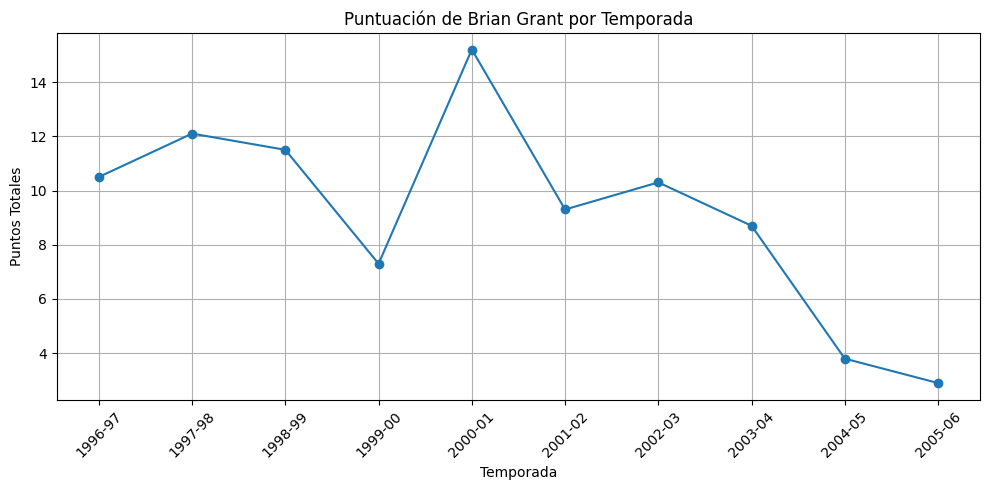

In [8]:
response = df.chat('Generame un chart donde se muestre la puntuación de Brian Grant por temporada')
response

In [9]:
print(response.last_code_executed)

import pandas as pd
import matplotlib.pyplot as plt
sql_query = """
SELECT season, SUM(pts) AS total_points
FROM table_nba_players_dataset
WHERE player_name = 'Brian Grant'
GROUP BY season
ORDER BY season
"""
brian_grant_data = execute_sql_query(sql_query)
plt.figure(figsize=(10, 5))
plt.plot(brian_grant_data['season'], brian_grant_data['total_points'], marker='o')
plt.title('Puntuación de Brian Grant por Temporada')
plt.xlabel('Temporada')
plt.ylabel('Puntos Totales')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
chart_filename = 'exports/charts/temp_chart_1cf3e11f-1859-4b2a-b1f5-aae2b7592dfd.png'
plt.savefig(chart_filename)
result = {'type': 'plot', 'value': chart_filename}


### 5 Push to Pandas AI Server

In [13]:
pai.api_key.set(os.getenv('PANDAS_AI_KEY'))
pandas_ai_account = os.getenv("PANDAS_AI_ACCOUNT")

In [ ]:
# Create dataset with semantic information
nba = pai.create(
    path=f"{pandas_ai_account}/nba",
    df = df,
    description="Dataset containing NBA player states",
    columns=[
        { "name": "id", "type": "integer", "description": "Identificador único del jugador" },
        { "name": "player_name", "type": "string", "description": "Nombre del jugador" },
        { "name": "team_abbreviation", "type": "string", "description": "Abreviatura del equipo del jugador" },
        { "name": "age", "type": "float", "description": "Edad del jugador" },
        { "name": "player_height", "type": "float", "description": "Altura del jugador" },
        { "name": "player_weight", "type": "float", "description": "Peso del jugador" },
        { "name": "college", "type": "string", "description": "Universidad a la que asistió el jugador" },
        { "name": "country", "type": "string", "description": "País de origen del jugador" },
        { "name": "draft_year", "type": "string", "description": "Año en que el jugador fue seleccionado en el draft de la NBA" },
        { "name": "draft_round", "type": "string", "description": "Ronda en la que el jugador fue seleccionado en el draft de la NBA" },
        { "name": "draft_number", "type": "string", "description": "Número de selección del jugador en el draft de la NBA" },
        { "name": "gp", "type": "integer", "description": "Partidos jugados" },
        { "name": "pts", "type": "float", "description": "Puntos por partido" },
        { "name": "reb", "type": "float", "description": "Rebotes por partido" },
        { "name": "ast", "type": "float", "description": "Asistencias por partido" },
        { "name": "net_rating", "type": "float", "description": "Net rating del jugador" },
        { "name": "oreb_pct", "type": "float", "description": "Porcentaje de rebotes ofensivos" },
        { "name": "dreb_pct", "type": "float", "description": "Porcentaje de rebotes defensivos" },
        { "name": "usg_pct", "type": "float", "description": "Porcentaje de uso" },
        { "name": "ts_pct", "type": "float", "description": "Porcentaje de tiro verdadero" },
        { "name": "ast_pct", "type": "float", "description": "Porcentaje de asistencias" },
        { "name": "season", "type": "string", "description": "Temporada a la que pertenecen las estadísticas" }
    ]
)

In [ ]:
dataset = pai.load(f"{pandas_ai_account}/nba")
dataset.push()